# Setup

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("../")

from utils.seed_all import seed_all

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

In [3]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.2)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

# Prediction

In [4]:
path = '../runs/tcn_pred_TOWIDS_20250912_155527/train_labels_predictions.pt'
cache = torch.load(path, weights_only=False)
y_true, y_out = cache['y_true'], cache['y_scores']
y_pred, y_scores = y_out
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

In [73]:
y_true['scores'] = y_scores.mean(axis=(1, 2))

In [74]:
y_true.head()

,label,start_idx,desc_windows,scores
0,Frame Injection,831090,"[Frame Injection, Frame Injection, Frame Injec...",6.126118e-05
1,Frame Injection,819979,"[Frame Injection, Frame Injection, Frame Injec...",2.164331e-08
2,Normal,4850,"[Normal, Normal, Normal, Normal, Normal, Norma...",3.269571e-07
3,Frame Injection,891142,"[Frame Injection, Frame Injection, Frame Injec...",9.690701e-08
4,Frame Injection,825359,"[Normal, Normal, Normal, Normal, Normal, Norma...",5.187680e-05


In [81]:
fn = y_true[(y_true['scores'] < 1.2369906698950217e-06) & (y_true['label'] != 'Normal')].index
tp = y_true[(y_true['scores'] >= 1.2369906698950217e-06) & (y_true['label'] != 'Normal')].index

In [92]:
desc_windows_fn = np.array([[j == 'Normal' for j in i] for i in y_true['desc_windows'].iloc[fn].values], dtype=int)
desc_windows_tp = np.array([[j == 'Normal' for j in i] for i in y_true['desc_windows'].iloc[tp].values], dtype=int)

In [93]:
desc_windows_fn.sum(1).std()

np.float64(16.091056572283257)

<Axes: ylabel='Frequency'>

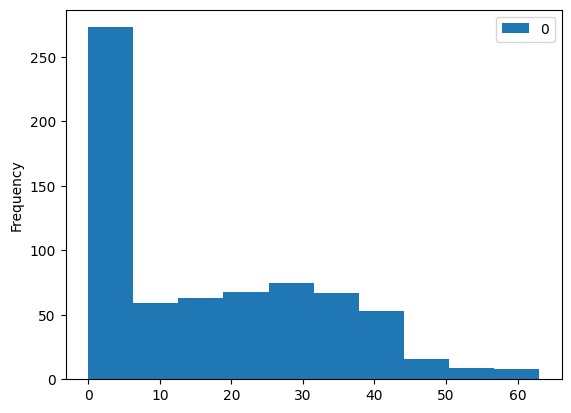

In [94]:
pd.DataFrame(desc_windows_fn.sum(1)).plot.hist()

<Axes: ylabel='Frequency'>

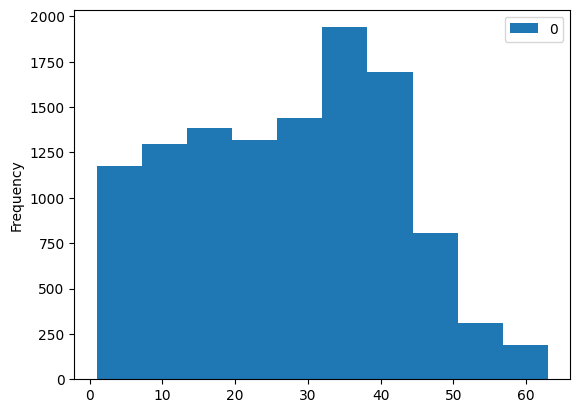

In [95]:
pd.DataFrame(desc_windows_tp.sum(1)).plot.hist()

In [97]:
from scipy.stats import ks_2samp

stat, p_value = ks_2samp(desc_windows_fn.sum(1), desc_windows_tp.sum(1))
print("KS test statistic:", stat)
print("p-value:", p_value)

KS test statistic: 0.31065052904621454
p-value: 2.1842886044517324e-56


In [ ]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(desc_windows_fn.sum(1), desc_windows_tp.sum(1))
print("Mann-Whitney U test statistic:", stat)
print("p-value:", p_value)

Mann-Whitney U test statistic: 2397476.0
p-value: 5.796525338992638e-70


In [85]:
desc_windows_tp.sum(1).std()

np.float64(14.39108653089795)

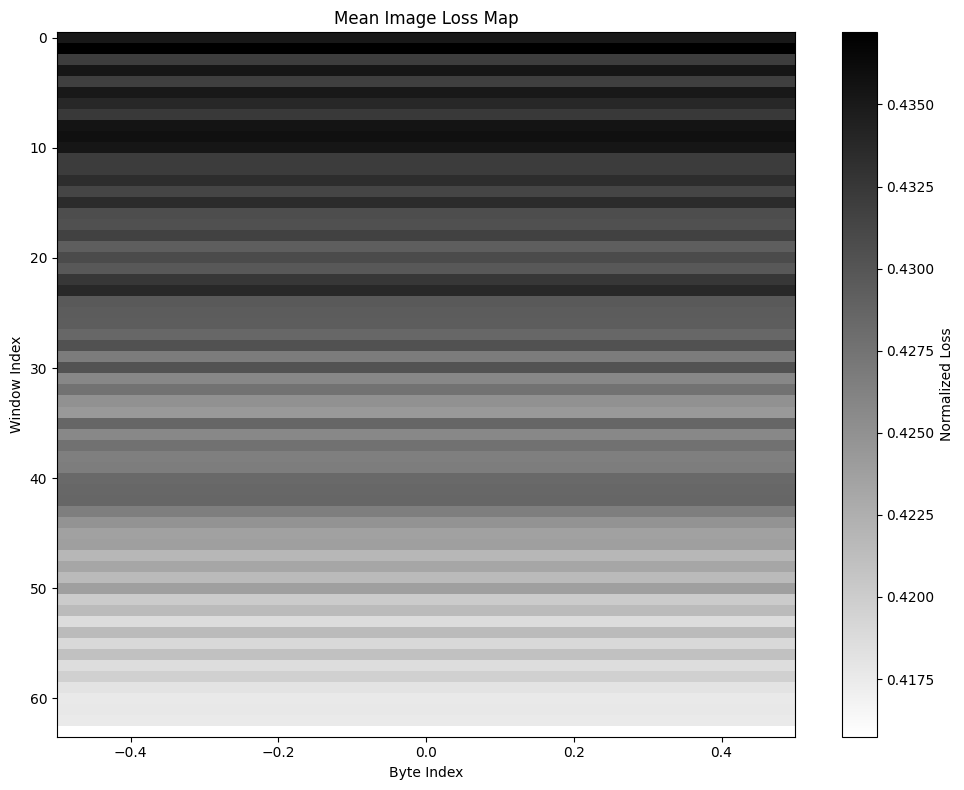

In [96]:
plot_img_loss(np.expand_dims(desc_windows_tp.mean(0), axis=1))

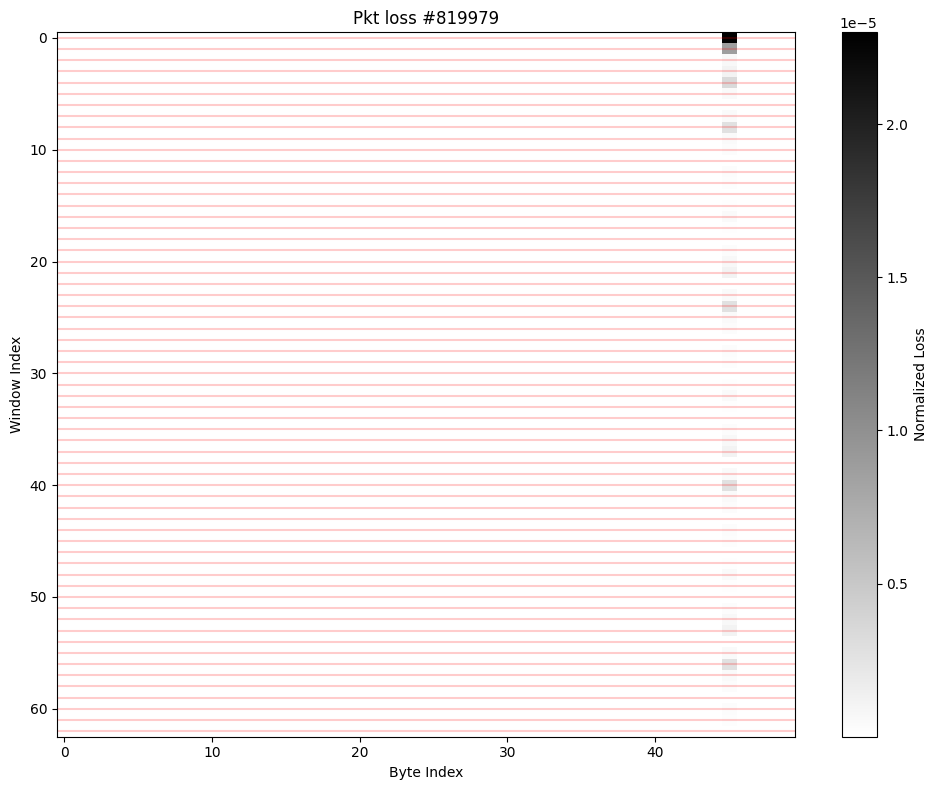

In [57]:
idx = fn[0]
plot_img_loss(y_scores[idx], targets=y_true['desc_windows'].iloc[idx][1:], name=f'Pkt loss #{y_true['start_idx'].iloc[idx]}')

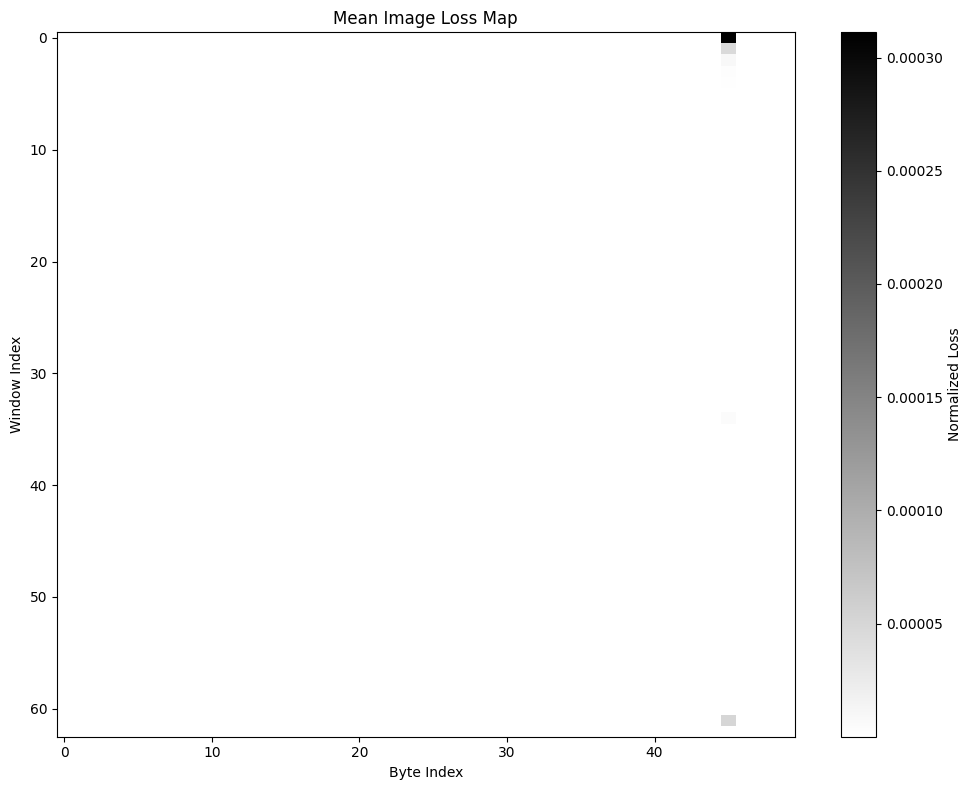

In [17]:
idx = y_true[y_true['label'] == 'Normal'].index
plot_img_loss(y_scores[fn].mean(0))

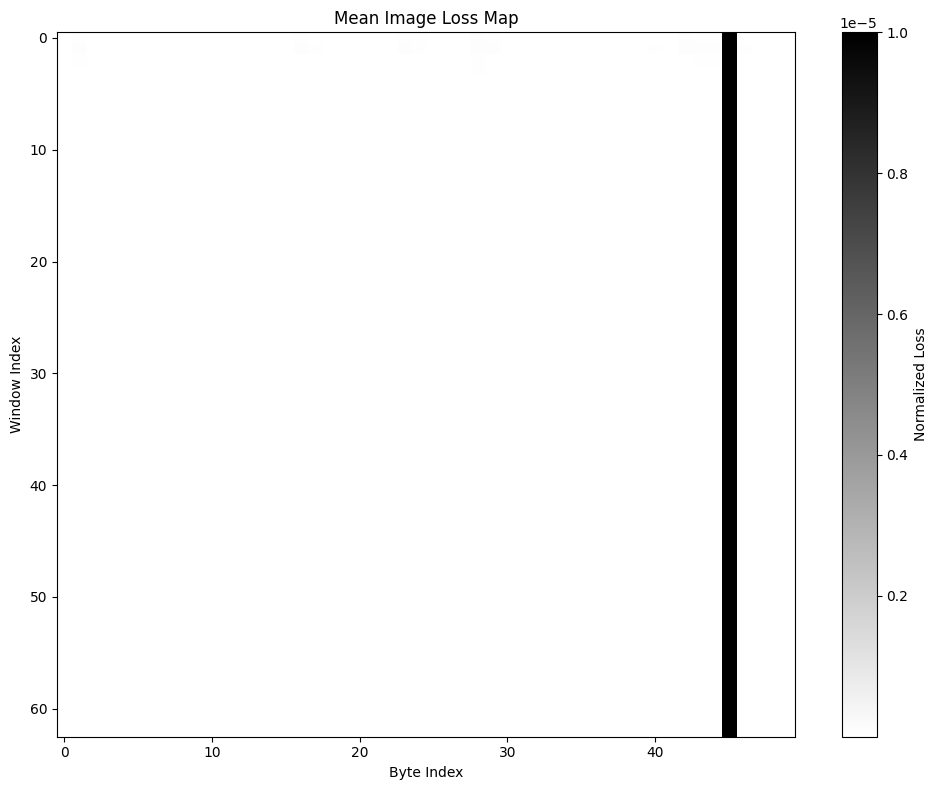

In [227]:
idx = y_true[y_true['label'] != 'Normal'].index
plot_img_loss(y_scores[idx].mean(0), max=0.00001)

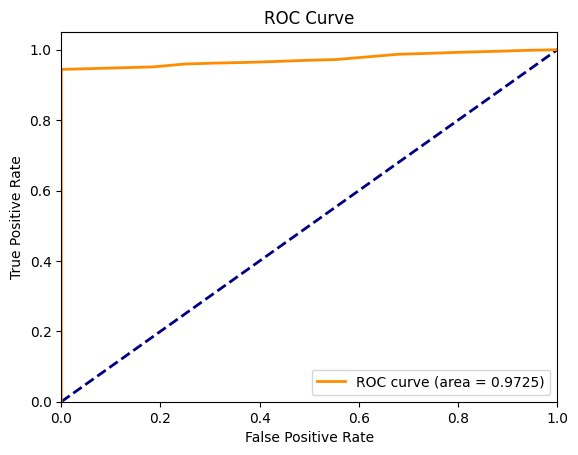

In [29]:
from sklearn.metrics import roc_auc_score, roc_curve


fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [56]:
fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
df_val_roc = pd.DataFrame({'fpr':fpr, 'tpr':tpr, 'thresholds':thresholds})
df_val_roc['youden-index'] = df_val_roc['tpr'] - df_val_roc['fpr']
df_val_roc.sort_values('youden-index', ascending=False).drop_duplicates('fpr')

,fpr,tpr,thresholds,youden-index
1635,0.000000,0.944005,0.003439,0.944005
1636,0.063977,0.946535,0.003045,0.882558
1637,0.123879,0.948821,0.002616,0.824941
1638,0.184841,0.951188,0.001030,0.766347
1639,0.249796,0.959432,0.000305,0.709636
1640,0.310432,0.962044,0.000182,0.651612
1641,0.371475,0.963840,0.000129,0.592365
1642,0.430888,0.966533,0.000100,0.535645
1643,0.492747,0.969798,0.000099,0.477052
1644,0.553627,0.972084,0.000087,0.418457
